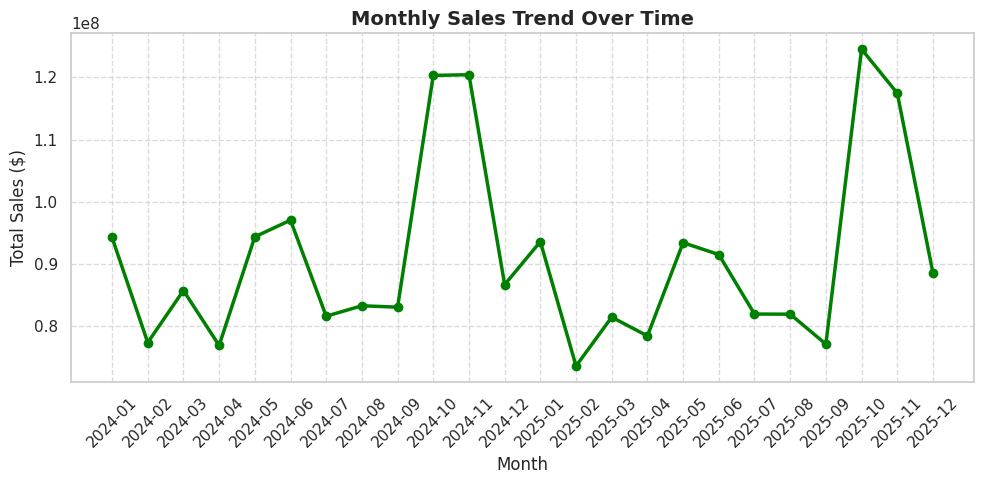

Setup aur Chart successfully run ho gaya hai!


In [15]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. CSV file ko load karna aur Database banana
# (Make sure aapki CSV file ka naam '/content/monthly_mobile_sales_50000.csv' ho)
df = pd.read_csv('monthly_mobile_sales_50000.csv')
conn = sqlite3.connect('mobile_sales_database.db')
df.to_sql('monthly_mobile_sales', conn, if_exists='replace', index=False)

# 2. Monthly Sales ka data SQL se nikalna
query_monthly = """
SELECT Month, SUM(Sales) as Monthly_Sales
FROM monthly_mobile_sales
GROUP BY Month;
"""
monthly_df = pd.read_sql(query_monthly, conn)

# 3. Line Chart Plot karna
plt.figure(figsize=(10, 5))
plt.plot(monthly_df['Month'], monthly_df['Monthly_Sales'], marker='o', color='green', linewidth=2.5)

plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Setup aur Chart successfully run ho gaya hai!")

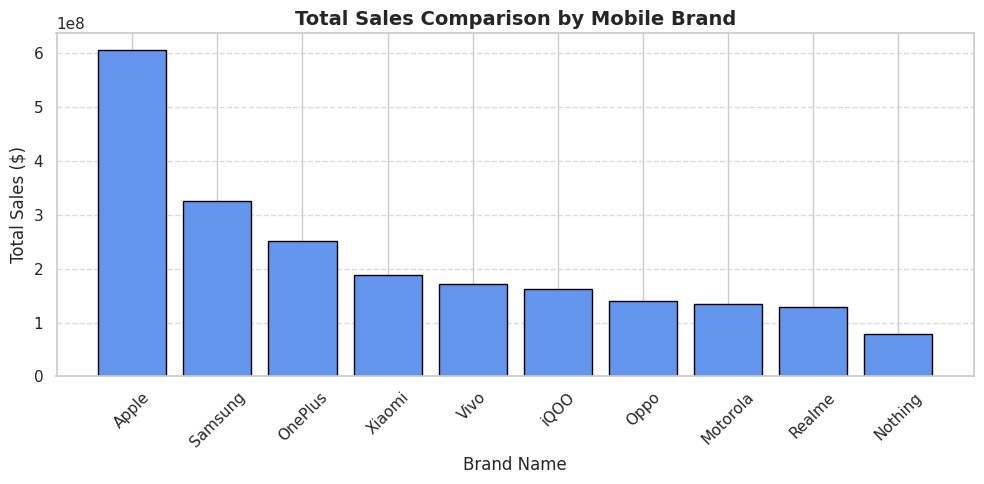

In [16]:
# 1. Brands ke hisaab se total sales nikalna
query_brands = """
SELECT Brand, SUM(Sales) as Total_Sales
FROM monthly_mobile_sales
GROUP BY Brand
ORDER BY Total_Sales DESC;
"""
brands_df = pd.read_sql(query_brands, conn)

# 2. Bar Chart banana
plt.figure(figsize=(10, 5))
plt.bar(brands_df['Brand'], brands_df['Total_Sales'], color='cornflowerblue', edgecolor='black')

# Title aur Labels
plt.title('Total Sales Comparison by Mobile Brand', fontsize=14, fontweight='bold')
plt.xlabel('Brand Name', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()